# Linear Regression: Predicting a Continuous Value

Practice fitting a linear regression model and visualizing the regression line.

Estimated time: 20 minutes

How to use: run top-to-bottom

## Learning objectives
- Build regression models using scikit-learn.
- Understand the intuition behind linear regression.
- Train a simple linear regression model to predict a continuous variable.
- Submit a plot of the regression line.

## 1) Setup
Imports, a fixed seed, and a quick summary helper.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def quick_summary(df, name):
    print(f"{name} shape: {df.shape}")
    print(df.head())
    print()

print("Setup complete ✅")

Setup complete ✅


## 2) Tiny data / inputs for today's topics
We will create a small dataset of study hours and a continuous final score.

In [3]:
n = 80
study_hours = rng.uniform(0, 10, n)
noise = rng.normal(0, 4, n)
final_score = 55 + 4.2 * study_hours + noise

df = pd.DataFrame({
    "study_hours": study_hours,
    "final_score": final_score
})

quick_summary(df, "df")
print(df.describe().T)

df shape: (80, 2)
   study_hours  final_score
0     7.739560    90.008516
1     4.388784    72.195508
2     8.585979    92.888214
3     6.973680    81.641753
4     0.941773    57.503233

             count       mean        std        min        25%        50%  \
study_hours   80.0   5.065484   2.718451   0.073623   2.865921   5.146422   
final_score   80.0  75.782132  12.490460  50.749983  66.232353  74.719675   

                   75%        max  
study_hours   7.588507   9.756224  
final_score  86.965684  97.708000  


## 3) Main task (guided)
Fit a linear regression model with a reproducible train/test split.

In [5]:
# TODO 1: choose the feature column
feature_col = "study_hours"

# TODO 2: choose the target column
target_col = "final_score"

# TODO 3: set test_size (e.g., 0.2)
test_size = 0.2

# TODO 4: set random_state for reproducibility
random_state = RANDOM_STATE

X = df[[feature_col]]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state
)

model = LinearRegression()
model.fit(X_train, y_train)

print("coef:", round(float(model.coef_[0]), 3))
print("intercept:", round(float(model.intercept_), 3))

coef: 4.389
intercept: 53.609


## 4) Verify / evaluate
Check error metrics and visualize the regression line.

MAE: 3.22
RMSE: 3.73


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


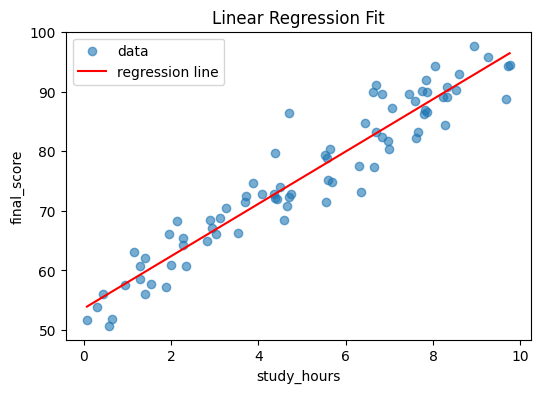

Interpretation: the line summarizes the average trend in the data.


In [6]:
y_pred = model.predict(X_test)
mae = np.mean(np.abs(y_test.values - y_pred))
rmse = np.sqrt(np.mean((y_test.values - y_pred) ** 2))

print("MAE:", round(float(mae), 2))
print("RMSE:", round(float(rmse), 2))

x_line = np.linspace(df[feature_col].min(), df[feature_col].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(6, 4))
plt.scatter(df[feature_col], df[target_col], alpha=0.6, label="data")
plt.plot(x_line, y_line, color="red", label="regression line")
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

print("Interpretation: the line summarizes the average trend in the data.")

## 5) Common pitfall + fix
Pitfall: evaluating only on training data. Fix: evaluate on a held-out test set.

In [8]:
train_pred = model.predict(X_train)
train_mae = np.mean(np.abs(y_train.values - train_pred))
test_pred = model.predict(X_test)
test_mae = np.mean(np.abs(y_test.values - test_pred))

print("Train MAE (optimistic):", round(float(train_mae), 2))
print("Test MAE (realistic):", round(float(test_mae), 2))
print("Fix: report test metrics to estimate real-world performance.")

Train MAE (optimistic): 2.86
Test MAE (realistic): 3.22
Fix: report test metrics to estimate real-world performance.
